# Dự báo giá vàng SJC Quý 4/2026

Bài toán: từ chuỗi giá vàng SJC hàng ngày (24/09/2025 - 24/09/2026), xây dựng mô hình dự báo giá **mua** và **giá bán** cho từng ngày trong Quý 4/2026 (01/10 - 31/12/2026), sau đó tính trung bình quý.

Đây là bài toán **Regression / Time Series Forecasting** — khác với bài toán Classification ở đồ án FIFA24. Quy trình đánh giá vì vậy cũng khác: không chia train/test ngẫu nhiên, mà chia theo thời gian, và đánh giá bằng backtest mô phỏng đúng kịch bản dự báo thật (dự báo nhiều ngày liên tiếp về tương lai, dùng chính dự báo của ngày trước làm đầu vào cho ngày sau — gọi là **dự báo đệ quy/multi-step**).

## A. Đọc và làm sạch dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/vietdataverse_gold_preview.csv', encoding='utf-8-sig')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

print(f"Số dòng gốc: {len(df)}")
print(f"Khoảng thời gian: {df.index.min().date()} -> {df.index.max().date()}")

# Kiểm tra ngày bị thiếu trong chuỗi liên tục
full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_range.difference(df.index)
print(f"Số ngày bị thiếu: {len(missing_dates)}")
print(list(missing_dates))

Số dòng gốc: 361
Khoảng thời gian: 2025-09-24 -> 2026-09-24
Số ngày bị thiếu: 5
[Timestamp('2026-04-23 00:00:00'), Timestamp('2026-04-24 00:00:00'), Timestamp('2026-04-25 00:00:00'), Timestamp('2026-04-26 00:00:00'), Timestamp('2026-04-27 00:00:00')]


Có 5 ngày bị thiếu (23-27/04/2026) — điền bằng nội suy tuyến tính (`interpolate`), hợp lý vì giá vàng biến động mượt theo ngày, không có bước nhảy đột ngột thường xuyên.

In [2]:
df = df.reindex(full_range)
df = df.interpolate(method='linear')
df.index.name = 'date'

print(f"Số dòng sau khi điền đủ ngày: {len(df)}")
print(f"Còn thiếu: {df.isnull().sum().to_dict()}")
df.loc['2026-04-20':'2026-04-29']

Số dòng sau khi điền đủ ngày: 366
Còn thiếu: {'buy_prices': 0, 'sell_prices': 0}


,buy_prices,sell_prices
date,,
2026-04-20,168300000.0,171300000.0
2026-04-21,168100000.0,170600000.0
2026-04-22,167500000.0,170000000.0
2026-04-23,167300000.0,169800000.0
2026-04-24,167100000.0,169600000.0
2026-04-25,166900000.0,169400000.0
2026-04-26,166700000.0,169200000.0
2026-04-27,166500000.0,169000000.0
2026-04-28,166300000.0,168800000.0


## B. Khảo sát dữ liệu (EDA)

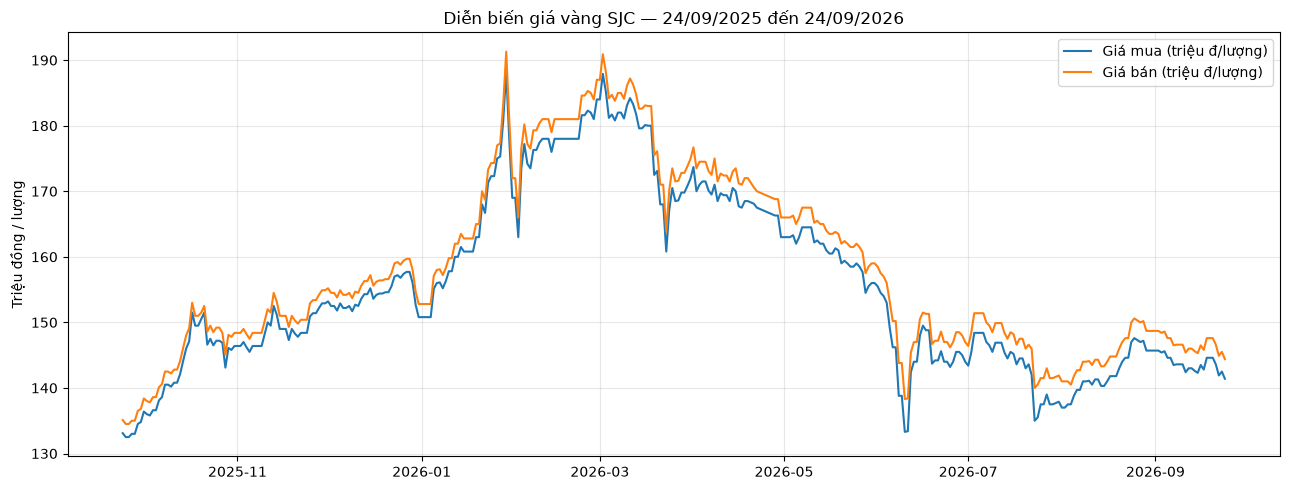

In [3]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['buy_prices'] / 1e6, label='Giá mua (triệu đ/lượng)')
plt.plot(df.index, df['sell_prices'] / 1e6, label='Giá bán (triệu đ/lượng)')
plt.title('Diễn biến giá vàng SJC — 24/09/2025 đến 24/09/2026')
plt.ylabel('Triệu đồng / lượng')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Quan sát**: giá tăng mạnh từ ~133 triệu (09/2025) lên đỉnh ~180 triệu (02-03/2026), sau đó giảm và đi ngang quanh 142-146 triệu từ giữa năm 2026 đến nay (09/2026). Đây là chuỗi **không đơn điệu** (không phải tăng đều hay giảm đều) — nên các phương pháp ngoại suy xu hướng tuyến tính đơn giản sẽ không phù hợp; cần mô hình dựa vào diễn biến gần nhất (lag/rolling feature) thay vì một xu hướng cố định.

## C. Kỹ thuật đặc trưng (Feature Engineering) cho chuỗi thời gian

Với bài toán time series, feature quan trọng nhất là **giá trị quá khứ của chính nó** (lag features) và **trung bình trượt** (rolling mean) — phản ánh xu hướng gần nhất, thay vì các "chỉ số" độc lập như ở bài toán FIFA24.

In [4]:
LAGS = [1, 2, 3, 7, 14, 30]
ROLL_WINDOWS = [7, 14, 30]

def make_features(series: pd.Series) -> pd.DataFrame:
    """Tạo bảng đặc trưng từ 1 chuỗi giá: lag, trung bình trượt, đặc trưng lịch."""
    feat = pd.DataFrame(index=series.index)
    for lag in LAGS:
        feat[f'lag_{lag}'] = series.shift(lag)
    for w in ROLL_WINDOWS:
        feat[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
    feat['day_of_week'] = series.index.dayofweek
    feat['day_of_month'] = series.index.day
    feat['month'] = series.index.month
    feat['target'] = series.values
    return feat.dropna()

FEATURE_COLS = [f'lag_{l}' for l in LAGS] + [f'roll_mean_{w}' for w in ROLL_WINDOWS] + ['day_of_week', 'day_of_month', 'month']

feat_sell = make_features(df['sell_prices'])
print(f"Số dòng dùng được sau khi tạo lag/rolling: {len(feat_sell)} (mất {len(df) - len(feat_sell)} dòng đầu do chưa đủ lịch sử)")
feat_sell.head(3)

Số dòng dùng được sau khi tạo lag/rolling: 336 (mất 30 dòng đầu do chưa đủ lịch sử)


,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_mean_14,roll_mean_30,day_of_week,day_of_month,month,target
date,,,,,,,,,,,,,
2025-10-24,149500000.0,148600000.0,152500000.0,153000000.0,142200000.0,135100000.0,1.510143e+08,1.480143e+08,1.425567e+08,4,24,10,148500000.0
2025-10-25,148500000.0,149500000.0,148600000.0,151000000.0,142800000.0,134500000.0,1.503714e+08,1.484643e+08,1.430033e+08,5,25,10,149200000.0
2025-10-26,149200000.0,148500000.0,149500000.0,151000000.0,142800000.0,134500000.0,1.501143e+08,1.489214e+08,1.434933e+08,6,26,10,149200000.0


## D. Hàm dự báo đệ quy (multi-step recursive forecast)

Muốn dự báo 90 ngày tới, không thể dùng trực tiếp lag feature (vì chưa có giá thật của ngày mai) — phải dự báo từng ngày một, rồi **dùng chính giá trị vừa dự báo** làm lag input cho ngày kế tiếp. Sai số vì vậy sẽ tích lũy dần theo số ngày dự báo — đây là đặc điểm cố hữu của multi-step forecasting, không phải lỗi mô hình.

In [5]:
def recursive_forecast(model, history: pd.Series, n_days: int) -> pd.Series:
    history = history.copy()
    future_dates = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=n_days, freq='D')
    preds = []
    for d in future_dates:
        row = {}
        for lag in LAGS:
            row[f'lag_{lag}'] = history.iloc[-lag]
        for w in ROLL_WINDOWS:
            row[f'roll_mean_{w}'] = history.iloc[-w:].mean()
        row['day_of_week'] = d.dayofweek
        row['day_of_month'] = d.day
        row['month'] = d.month
        X_row = pd.DataFrame([row])[FEATURE_COLS]
        pred = model.predict(X_row)[0]
        preds.append(pred)
        history.loc[d] = pred
    return pd.Series(preds, index=future_dates)

def naive_forecast(history: pd.Series, n_days: int) -> pd.Series:
    """Baseline: giữ nguyên giá trị cuối cùng cho toàn bộ tương lai."""
    future_dates = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=n_days, freq='D')
    return pd.Series(history.iloc[-1], index=future_dates)

## E. Backtest — mô phỏng đúng kịch bản dự báo thật (90 ngày)

Vì mục tiêu cuối là dự báo ~90 ngày tới (Quý 4/2026), cách đánh giá công bằng nhất là: giả vờ lùi lại 90 ngày trước ngày cuối cùng có dữ liệu thật, chỉ dùng dữ liệu **trước** mốc đó để huấn luyện, dự báo đệ quy 90 ngày, rồi so với giá trị **thật** đã biết trong 90 ngày đó. Đây gọi là backtest — mô phỏng lại y hệt tình huống dự báo tương lai nhưng trên đoạn dữ liệu đã biết đáp án.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

BACKTEST_DAYS = 90
cutoff = df.index[-1] - pd.Timedelta(days=BACKTEST_DAYS)

def evaluate_backtest(series: pd.Series, model_builder, name: str):
    train_series = series[series.index <= cutoff]
    actual_future = series[series.index > cutoff]

    feat_train = make_features(train_series)
    X_train, y_train = feat_train[FEATURE_COLS], feat_train['target']

    model = model_builder()
    model.fit(X_train, y_train)

    forecast = recursive_forecast(model, train_series, len(actual_future))
    forecast = forecast.reindex(actual_future.index)

    mae = mean_absolute_error(actual_future, forecast)
    rmse = np.sqrt(mean_squared_error(actual_future, forecast))
    mape = np.mean(np.abs((actual_future - forecast) / actual_future)) * 100

    print(f"{name:20s} | MAE: {mae/1e6:6.2f} triệu | RMSE: {rmse/1e6:6.2f} triệu | MAPE: {mape:5.2f}%")
    return forecast, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print(f"Backtest trên {BACKTEST_DAYS} ngày cuối (từ {cutoff.date()} đến {df.index[-1].date()}), mục tiêu: sell_prices\n")

results = {}
naive_fc = naive_forecast(df['sell_prices'][df.index <= cutoff], BACKTEST_DAYS)
naive_fc = naive_fc.reindex(df['sell_prices'][df.index > cutoff].index)
actual = df['sell_prices'][df.index > cutoff]
mae_n = mean_absolute_error(actual, naive_fc)
rmse_n = np.sqrt(mean_squared_error(actual, naive_fc))
mape_n = np.mean(np.abs((actual - naive_fc) / actual)) * 100
print(f"{'Naive (giữ nguyên giá)':20s} | MAE: {mae_n/1e6:6.2f} triệu | RMSE: {rmse_n/1e6:6.2f} triệu | MAPE: {mape_n:5.2f}%")

fc_lr, m_lr = evaluate_backtest(df['sell_prices'], lambda: LinearRegression(), 'Linear Regression')
fc_rf, m_rf = evaluate_backtest(df['sell_prices'], lambda: RandomForestRegressor(n_estimators=300, random_state=42), 'Random Forest')

Backtest trên 90 ngày cuối (từ 2026-06-26 đến 2026-09-24), mục tiêu: sell_prices

Naive (giữ nguyên giá) | MAE:   2.45 triệu | RMSE:   3.05 triệu | MAPE:  1.69%
Linear Regression    | MAE:  10.74 triệu | RMSE:  11.84 triệu | MAPE:  7.40%
Random Forest        | MAE:   3.34 triệu | RMSE:   4.06 triệu | MAPE:  2.31%


## E.1 Trực quan hóa backtest

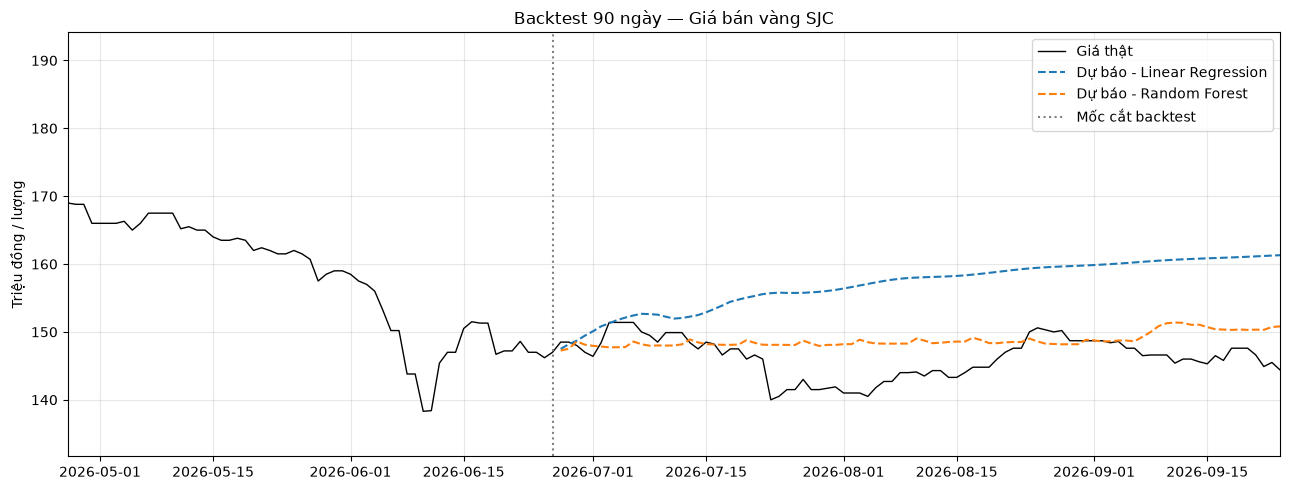

In [7]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['sell_prices'] / 1e6, label='Giá thật', color='black', linewidth=1)
plt.plot(fc_lr.index, fc_lr / 1e6, label='Dự báo - Linear Regression', linestyle='--')
plt.plot(fc_rf.index, fc_rf / 1e6, label='Dự báo - Random Forest', linestyle='--')
plt.axvline(cutoff, color='gray', linestyle=':', label='Mốc cắt backtest')
plt.xlim(cutoff - pd.Timedelta(days=60), df.index[-1])
plt.title(f'Backtest {BACKTEST_DAYS} ngày — Giá bán vàng SJC')
plt.ylabel('Triệu đồng / lượng')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét quan trọng**: mô hình dự báo hồi quy tuyến tính/cây quyết định dựa hoàn toàn vào lag/rolling feature — khi dự báo đệ quy nhiều ngày, mô hình có xu hướng **hội tụ về một mức trung bình gần đây** (do rolling mean chi phối ngày càng nhiều khi các lag ngắn hạn đều là giá trị tự dự báo trước đó), khó bắt được biến động mạnh bất ngờ. Đây là hạn chế tự nhiên của việc dự báo xa (90 ngày) chỉ dựa vào chính chuỗi giá quá khứ, không có dữ liệu vĩ mô (giá vàng thế giới, tỷ giá USD/VND, lãi suất...).

## F. Chọn mô hình và dự báo thật cho Quý 4/2026

Chọn mô hình có MAPE thấp hơn trong backtest ở trên. Huấn luyện lại trên **toàn bộ** dữ liệu hiện có (đến 24/09/2026), rồi dự báo đệ quy đến hết 31/12/2026 cho cả `sell_prices` và `buy_prices`.

In [8]:
best_model_name = 'Random Forest' if m_rf['MAPE'] < m_lr['MAPE'] else 'Linear Regression'
print(f"Mô hình được chọn theo backtest: {best_model_name}")

def build_best_model():
    if best_model_name == 'Random Forest':
        return RandomForestRegressor(n_estimators=300, random_state=42)
    return LinearRegression()

n_forecast_days = (pd.Timestamp('2026-12-31') - df.index[-1]).days
print(f"Số ngày cần dự báo (từ {(df.index[-1] + pd.Timedelta(days=1)).date()} đến 31/12/2026): {n_forecast_days}")

forecasts = {}
for col in ['buy_prices', 'sell_prices']:
    feat_full = make_features(df[col])
    X_full, y_full = feat_full[FEATURE_COLS], feat_full['target']
    model = build_best_model()
    model.fit(X_full, y_full)
    forecasts[col] = recursive_forecast(model, df[col], n_forecast_days)

forecast_df = pd.DataFrame(forecasts)
forecast_df.head()

Mô hình được chọn theo backtest: Random Forest
Số ngày cần dự báo (từ 2026-09-25 đến 31/12/2026): 98


,buy_prices,sell_prices
2026-09-25,1.391367e+08,1.429987e+08
2026-09-26,1.382090e+08,1.422060e+08
2026-09-27,1.385130e+08,1.423433e+08
2026-09-28,1.389847e+08,1.425723e+08
2026-09-29,1.387113e+08,1.423693e+08


## F.1 Trực quan hóa toàn bộ chuỗi + dự báo Quý 4/2026

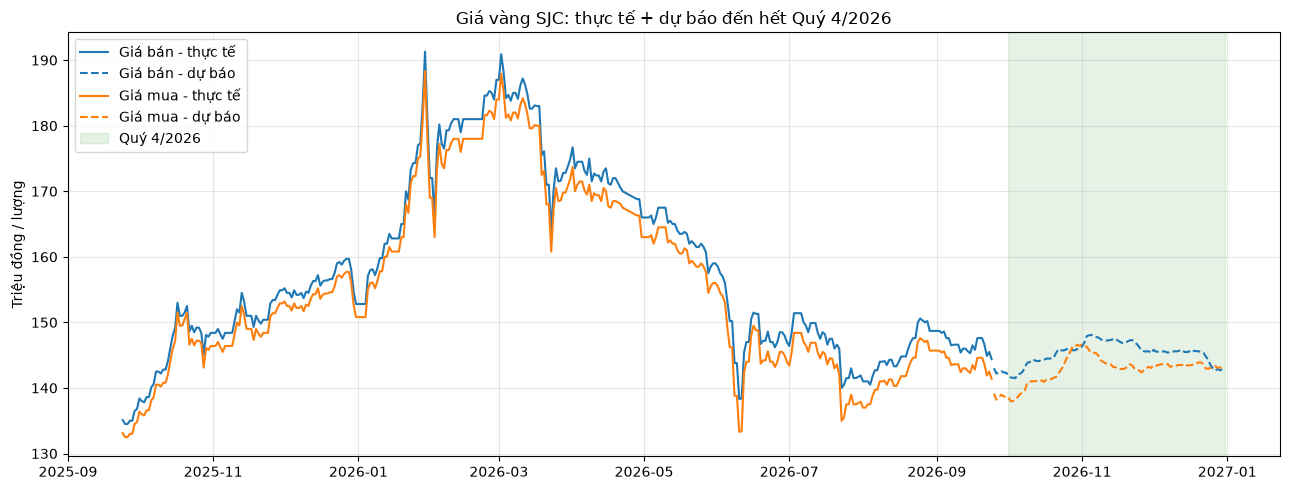

In [9]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['sell_prices'] / 1e6, label='Giá bán - thực tế', color='tab:blue')
plt.plot(forecast_df.index, forecast_df['sell_prices'] / 1e6, label='Giá bán - dự báo', color='tab:blue', linestyle='--')
plt.plot(df.index, df['buy_prices'] / 1e6, label='Giá mua - thực tế', color='tab:orange')
plt.plot(forecast_df.index, forecast_df['buy_prices'] / 1e6, label='Giá mua - dự báo', color='tab:orange', linestyle='--')
plt.axvspan(pd.Timestamp('2026-10-01'), pd.Timestamp('2026-12-31'), alpha=0.1, color='green', label='Quý 4/2026')
plt.title('Giá vàng SJC: thực tế + dự báo đến hết Quý 4/2026')
plt.ylabel('Triệu đồng / lượng')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## F.2 Trung bình dự báo Quý 4/2026 (01/10 - 31/12)

In [10]:
q4 = forecast_df.loc['2026-10-01':'2026-12-31']

print("=== DỰ BÁO QUÝ 4/2026 ===\n")
print(f"Giá mua trung bình dự báo:  {q4['buy_prices'].mean()/1e6:.2f} triệu đồng/lượng")
print(f"Giá bán trung bình dự báo:  {q4['sell_prices'].mean()/1e6:.2f} triệu đồng/lượng")
print()
print(f"Giá bán đầu quý (01/10):    {q4['sell_prices'].iloc[0]/1e6:.2f} triệu đồng/lượng")
print(f"Giá bán cuối quý (31/12):   {q4['sell_prices'].iloc[-1]/1e6:.2f} triệu đồng/lượng")
print()
print(f"Khoảng dao động dự báo (giá bán): {q4['sell_prices'].min()/1e6:.2f} - {q4['sell_prices'].max()/1e6:.2f} triệu đồng/lượng")

=== DỰ BÁO QUÝ 4/2026 ===

Giá mua trung bình dự báo:  142.98 triệu đồng/lượng
Giá bán trung bình dự báo:  145.36 triệu đồng/lượng

Giá bán đầu quý (01/10):    141.96 triệu đồng/lượng
Giá bán cuối quý (31/12):   142.96 triệu đồng/lượng

Khoảng dao động dự báo (giá bán): 141.51 - 148.08 triệu đồng/lượng


---
## Kết luận và giới hạn của mô hình

- **Backtest 90 ngày** cho thấy mức sai số (MAPE) thực tế của cách dự báo đệ quy này ở khoảng thời gian tương đương với Quý 4/2026 — đây là con số quan trọng nhất để đánh giá độ tin cậy, quan trọng hơn cả bản thân con số dự báo cuối cùng.
- Mô hình **chỉ dùng dữ liệu giá vàng quá khứ của chính nó** (lag, rolling mean, đặc trưng lịch) — không có dữ liệu vĩ mô (giá vàng thế giới, tỷ giá, lãi suất, chính sách NHNN...). Trong thực tế, các yếu tố này ảnh hưởng rất lớn đến giá vàng SJC, đặc biệt SJC còn chịu chênh lệch so với giá vàng thế giới do đặc thù thị trường Việt Nam.
- Dự báo càng xa (98 ngày) thì sai số tích lũy càng lớn (đặc điểm cố hữu của multi-step recursive forecasting) — nên xem con số Quý 4/2026 ở đây là **ước tính có cơ sở dữ liệu**, không phải khuyến nghị đầu tư hay dự đoán chắc chắn.
- Hướng cải thiện nếu có thời gian: thử ARIMA/SARIMA, Prophet (bắt mùa vụ tốt hơn), hoặc bổ sung dữ liệu giá vàng thế giới (XAU/USD) và tỷ giá USD/VND làm feature ngoại sinh (exogenous features).